# **Machine Learning para Predições em Saude**




---


PROBLEMA DE REGRESSÃO

In [ ]:
import pandas as pd # para processamento de bancos de dados
import numpy as np # para processamento numérico de bancos de dados
import matplotlib.pyplot as plt # para geração de gráficos
from matplotlib import rc  # configurações adicionais para os gráficos a serem gerados
import seaborn as sns #alternativa para a matplotlib para geração de gráficos

# definimos o estilo dos gráficos
# mais estilos em https://matplotlib.org/3.1.1/gallery/#style-sheets
import operator  # para ordenação do zip
from sklearn.model_selection import train_test_split  # importamos a funcionalidade de split do conjunto de dados em treino/teste
from sklearn.metrics import mean_squared_error, r2_score  # métricas de performance para modelos de regressão
from sklearn.feature_selection import VarianceThreshold

### Importando o conjunto de dados como um Pandas DataFrame

In [ ]:
# Ler o arquivo CSV
df = pd.read_csv('bancoregressao_EV.csv')

# Mostrar as primeiras linhas
print(df.head())

   cod_municipio  ExpecVida  PopResid  idoso  mulher  nascimentopercapta  \
0        1100015      70.75     24392   8.79   48.11               16.70   
1        1100023      73.36     90353   6.67   49.59               18.05   
2        1100031      70.39      6313  10.09   48.27               15.06   
3        1100049      74.27     78574   8.10   50.21               15.74   
4        1100056      72.94     17029   9.97   49.79               14.13   

   casado  evangelico  deficiente  desindadepop  ...  nvelsuperiorconcludo  \
0   38.63       26.90       23.88          3.45  ...                  5.50   
1   30.13       33.67       21.60         20.41  ...                  8.16   
2   43.90       28.56       23.77          4.80  ...                  4.93   
3   42.25       39.04       25.34         20.72  ...                  8.74   
4   41.66       29.89       24.97          6.12  ...                  7.01   

   conclusoensinomdio  ResideMenos10anos  resideoutranacionalid  \
0      

In [ ]:
# verificando as características básicas do conjunto de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5565 entries, 0 to 5564
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cod_municipio          5565 non-null   int64  
 1   ExpecVida              5565 non-null   float64
 2   PopResid               5565 non-null   int64  
 3   idoso                  5565 non-null   float64
 4   mulher                 5565 non-null   float64
 5   nascimentopercapta     5565 non-null   float64
 6   casado                 5565 non-null   float64
 7   evangelico             5565 non-null   float64
 8   deficiente             5565 non-null   float64
 9   desindadepop           5565 non-null   float64
 10  geladeira              5565 non-null   float64
 11  moradorfavela          5565 non-null   float64
 12  pavimentacao           5565 non-null   float64
 13  brancos                5565 non-null   float64
 14  nvelsuperiorconcludo   5565 non-null   float64
 15  conc

### Seleção de municípios com mais de 10.000 habitantes

In [ ]:
df_filtro = df[df['PopResid'] > 10000]

In [ ]:
# estatísticas básicas do conjuntos de dados
df_filtro.describe().T

,count,mean,std,min,25%,50%,75%,max
cod_municipio,3052.0,3.116082e+06,963249.105196,1100015.00,2.501881e+06,3109808.000,3.548527e+06,5300108.00
ExpecVida,3052.0,7.297854e+01,2.778115,65.55,7.085000e+01,73.260,7.522000e+01,78.64
PopResid,3052.0,5.826983e+04,271948.105796,10004.00,1.414875e+04,21498.000,3.979725e+04,11253503.00
idoso,3052.0,1.104916e+01,2.855370,2.63,9.107500e+00,11.130,1.309000e+01,20.40
mulher,3052.0,4.987794e+01,1.414421,38.71,4.912750e+01,50.040,5.082000e+01,54.24
nascimentopercapta,3052.0,1.498205e+01,3.302594,5.97,1.272750e+01,14.535,1.678000e+01,35.17
casado,3052.0,3.425608e+01,8.097012,6.55,2.904250e+01,35.115,4.061000e+01,53.42
evangelico,3052.0,1.829714e+01,9.159141,2.03,1.104000e+01,17.260,2.445250e+01,77.26
deficiente,3052.0,2.418847e+01,4.128437,10.19,2.131750e+01,24.065,2.688000e+01,38.79
desindadepop,3052.0,1.770068e+02,764.840624,0.20,1.610750e+01,36.060,8.729250e+01,13024.60


### Separar conjunto de dados em treinamento e teste

In [ ]:
# variável de interesse
desfecho = df_filtro['ExpecVida']

# removemos a coluna ExpecVida e cod_municipio do conjunto de dados (axis = 1 representa coluna. Inplace é para atualizar a variável)
df_filtro.drop(['ExpecVida', 'cod_municipio'], axis = 1, inplace = True)

/tmp/ipykernel_469/4002761338.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtro.drop(['ExpecVida', 'cod_municipio'], axis = 1, inplace = True)


In [ ]:
# fazemos a separação do conjunto de dados em treino/teste, com 30% dos dados para teste
X_train, X_test, y_train, y_test = train_test_split(df_filtro, desfecho, test_size=0.3)

In [ ]:
X_train.shape #quantidade de registros para treino (linhas, colunas)

(2136, 22)

In [ ]:
X_test.shape #quantidade de registros para teste (linhas, colunas)

(916, 22)

### Pré-processamento dos dados de treinamento

#### Variáveis quantitativas

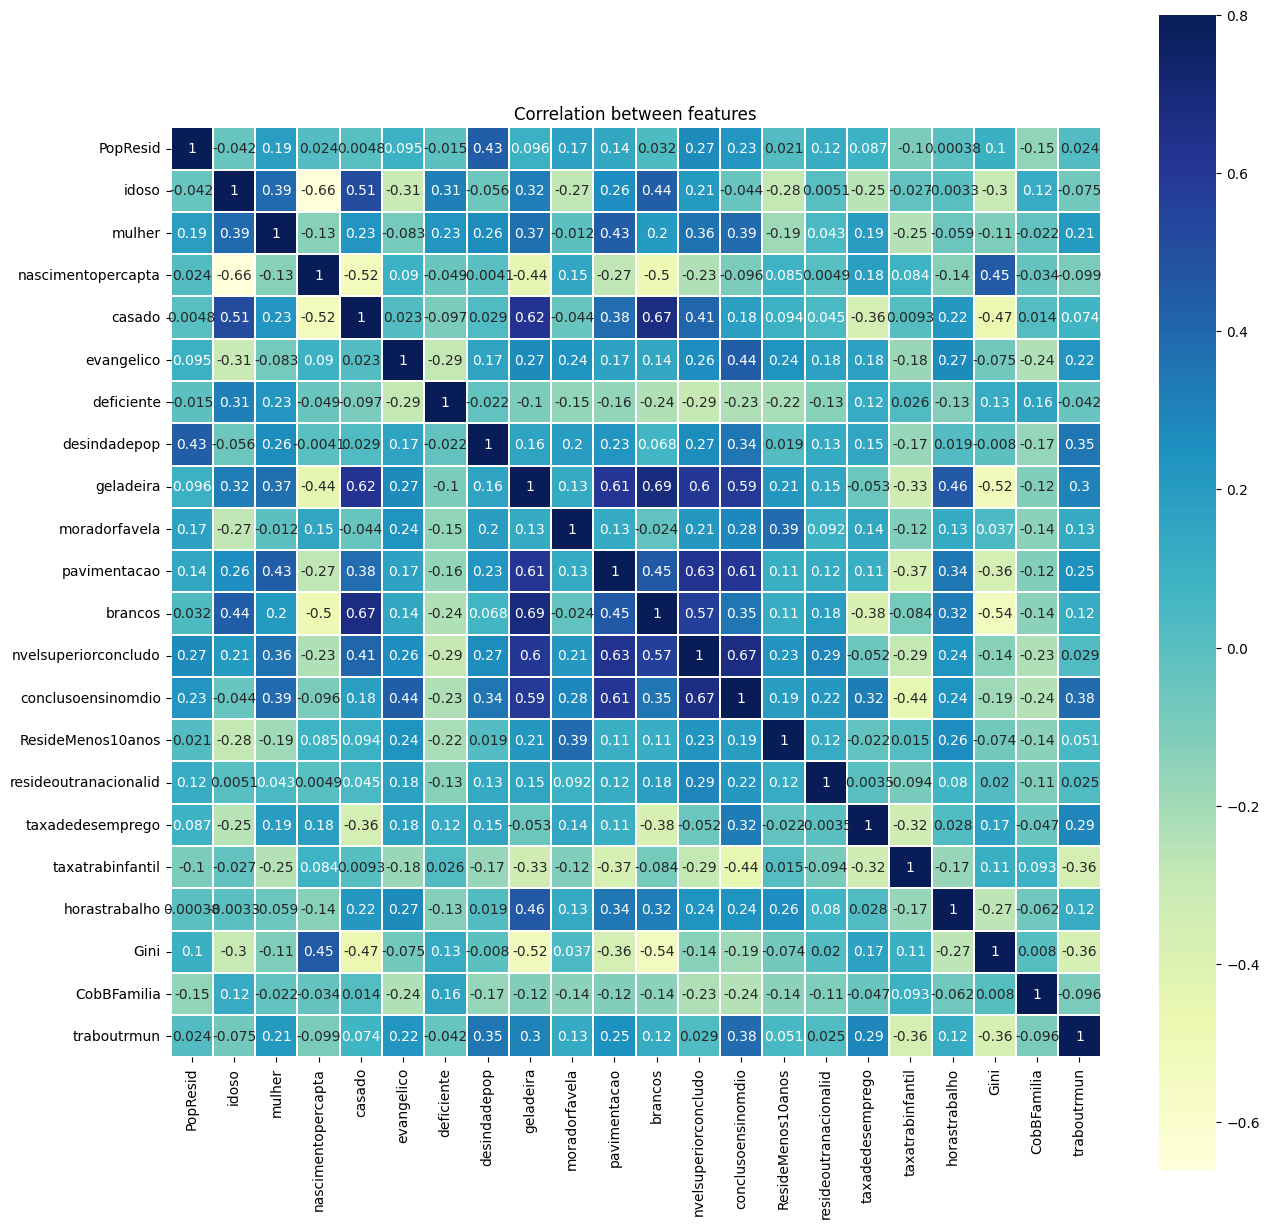

In [ ]:
# verificando a correlação entre as variáveis

# método de Pearson
corr=X_train.corr(method='pearson')
plt.figure(figsize=(15, 15))
sns.heatmap(corr, vmax=.8, linewidths=0.01,
          square=True,annot=True,cmap='YlGnBu',linecolor="white")
plt.title('Correlation between features')
plt.show()

### Filtrar preditores com variância nula

In [ ]:
# Escolha o limiar aceitável de variância
threshold = 0

selector = VarianceThreshold(threshold)
selector.fit_transform(X_train)

array([[1.5409e+04, 1.1000e+01, 4.9000e+01, ..., 4.5000e-01, 1.0000e+02,
        2.7000e+00],
       [3.2168e+04, 1.0910e+01, 4.8810e+01, ..., 5.3000e-01, 3.7560e+01,
        4.3000e+00],
       [3.2366e+04, 8.6700e+00, 4.9560e+01, ..., 5.4000e-01, 8.7110e+01,
        1.3930e+01],
       ...,
       [3.1056e+04, 1.4030e+01, 5.0640e+01, ..., 4.6000e-01, 6.6040e+01,
        8.7200e+00],
       [4.0750e+04, 1.2490e+01, 5.1340e+01, ..., 4.6000e-01, 8.2580e+01,
        2.6140e+01],
       [1.4598e+04, 1.1110e+01, 4.9960e+01, ..., 4.1000e-01, 6.8540e+01,
        3.3000e+00]])

In [ ]:
selector.variances_

array([1.12434990e+07, 8.27720480e+00, 2.08601716e+00, 1.10133343e+01,
       4.68700000e+01, 7.52300000e+01, 1.72414865e+01, 1.30244000e+04,
       7.00200000e+01, 1.56956647e-01, 5.98445161e-02, 9.13200000e+01,
       1.46077947e+01, 4.29800000e+01, 2.25946545e+01, 6.43164657e-02,
       3.53057178e+00, 3.83670070e+01, 6.01500000e+01, 3.77869999e-03,
       1.00000000e+02, 6.50400000e+01])

In [ ]:
X_train.columns

Index(['PopResid', 'idoso', 'mulher', 'nascimentopercapta', 'casado',
       'evangelico', 'deficiente', 'desindadepop', 'geladeira',
       'moradorfavela', 'pavimentacao', 'brancos', 'nvelsuperiorconcludo',
       'conclusoensinomdio', 'ResideMenos10anos', 'resideoutranacionalid',
       'taxadedesemprego', 'taxatrabinfantil', 'horastrabalho', 'Gini',
       'CobBFamilia', 'traboutrmun'],
      dtype='object')

In [ ]:
for i,s in enumerate(selector.get_support()):
  if s:
    print(X_train.columns[i] + " - manter " + "["+ str(selector.variances_[i]) + "]")
  else:
    print("*** " + X_train.columns[i] + " - remover " + "["+ str(selector.variances_[i]) + "]")

PopResid - manter [11243499.0]
idoso - manter [8.277204804738458]
mulher - manter [2.086017160080798]
nascimentopercapta - manter [11.01333432224379]
casado - manter [46.870000000000005]
evangelico - manter [75.23]
deficiente - manter [17.241486535440252]
desindadepop - manter [13024.4]
geladeira - manter [70.02]
moradorfavela - manter [0.15695664686610133]
pavimentacao - manter [0.05984451613765799]
brancos - manter [91.32000000000001]
nvelsuperiorconcludo - manter [14.607794663951488]
conclusoensinomdio - manter [42.98]
ResideMenos10anos - manter [22.59465449278202]
resideoutranacionalid - manter [0.06431646570210692]
taxadedesemprego - manter [3.5305717835149886]
taxatrabinfantil - manter [38.367007038515766]
horastrabalho - manter [60.15]
Gini - manter [0.003778699992284925]
CobBFamilia - manter [100.0]
traboutrmun - manter [65.04]


In [ ]:
# verificar variáveis constantes

In [ ]:
constant_features = [
    feat for feat in X_train.columns if X_train[feat].std() == 0
]

In [ ]:
constant_features

[]

### Padronizar os dados de treino e teste

In [ ]:
X_train_tidy = X_train.melt() #serve para transformar o DataFrame de formato "largo" (wide) para "longo" (long/tidy).

In [ ]:
X_train_tidy = X_train.melt()
plot = X_train_tidy[X_train_tidy['variable'].isin(['casado', 'idoso', 'geladeira', 'taxatrabinfantil'])]

Text(0.5, 1.0, 'Antes de Padronizar')

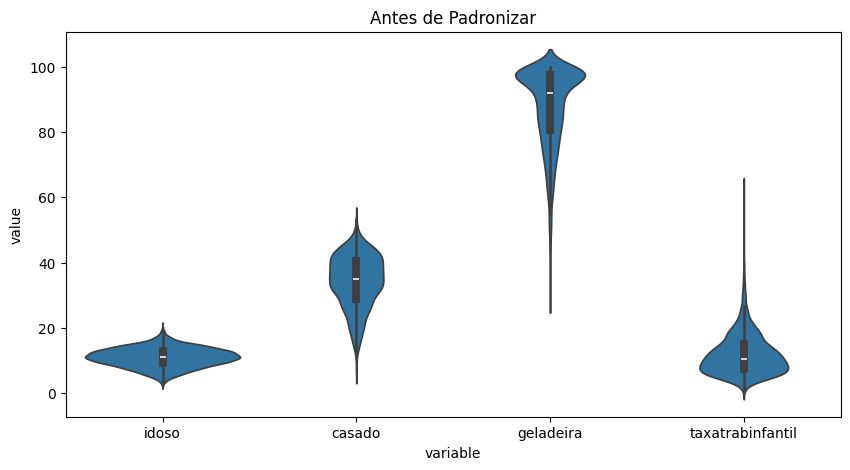

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(data=plot, x= 'variable', y='value')
plt.title("Antes de Padronizar")

In [ ]:
# importamos a funcao StandardScaler para padronização dos dados
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()

In [ ]:
# obtemos as estatísticas necessárias para a padronização a partir do conjunto de treinamento
sc.fit(X_train)

StandardScaler()

In [ ]:
sc.mean_

array([5.83976915e+04, 1.10279775e+01, 4.98655056e+01, 1.50087406e+01,
       3.41827154e+01, 1.84807678e+01, 2.42715543e+01, 1.84480047e+02,
       8.75074719e+01, 1.71633895e-01, 4.90079588e-01, 4.33542416e+01,
       6.04197097e+00, 1.77086002e+01, 5.74561330e+00, 8.51170412e-02,
       4.24464419e+00, 1.18718820e+01, 2.80459129e+01, 5.19428839e-01,
       7.21532912e+01, 1.09441573e+01])

In [ ]:
sc.var_

array([7.93950998e+10, 8.27720480e+00, 2.08601716e+00, 1.10133343e+01,
       6.48726824e+01, 8.45035433e+01, 1.72414865e+01, 6.47170494e+05,
       1.53174936e+02, 1.56956647e-01, 5.98445161e-02, 5.11711920e+02,
       1.46077947e+01, 4.43167676e+01, 2.25946545e+01, 6.43164657e-02,
       3.53057178e+00, 3.83670070e+01, 8.86723031e+01, 3.77869999e-03,
       3.82825368e+02, 1.20588461e+02])

In [ ]:
# padronizamos o conjunto de treinamento
X_train = pd.DataFrame(sc.transform(X_train), columns=X_train.columns)

In [ ]:
# padronizamos o conjunto de teste
X_test = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)

In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PopResid,2136.0,1.496930e-17,1.000234,-0.171748,-0.156904,-0.131361,-0.067287,39.731168
idoso,2136.0,-1.879479e-16,1.000234,-2.918992,-0.664049,0.028510,0.709772,3.257553
mulher,2136.0,1.570945e-15,1.000234,-7.723788,-0.543864,0.110430,0.660868,3.028788
nascimentopercapta,2136.0,4.773543e-16,1.000234,-2.723633,-0.674597,-0.144258,0.533731,6.075167
casado,2136.0,6.154045e-17,1.000234,-3.430778,-0.656504,0.103954,0.777192,2.388432
evangelico,2136.0,1.925218e-16,1.000234,-1.789570,-0.783324,-0.117026,0.673014,6.394203
deficiente,2136.0,-3.991813e-17,1.000234,-3.391277,-0.690356,-0.030478,0.654686,3.496494
desindadepop,2136.0,-1.829581e-17,1.000234,-0.229070,-0.209989,-0.185122,-0.120368,15.960986
geladeira,2136.0,1.530195e-16,1.000234,-4.648164,-0.568015,0.346832,0.812235,1.009384
moradorfavela,2136.0,-2.993860e-17,1.000234,-0.433225,-0.433225,-0.357501,0.021117,18.245270


In [ ]:
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
PopResid,916.0,-0.001512,0.878384,-0.171631,-0.157705,-0.128848,-0.062916,22.223864
idoso,916.0,0.024537,0.974474,-2.658305,-0.674476,0.059792,0.745399,2.684041
mulher,916.0,0.028690,0.928907,-7.564541,-0.474627,0.141587,0.634904,2.689525
nascimentopercapta,916.0,-0.026796,0.983535,-2.419290,-0.707743,-0.141245,0.531471,5.008464
casado,916.0,0.030350,1.017234,-3.104247,-0.599392,0.137476,0.846720,2.153776
evangelico,916.0,-0.066555,0.986246,-1.676435,-0.868991,-0.163259,0.539754,3.428769
deficiente,916.0,-0.066669,0.979128,-2.697683,-0.761401,-0.111157,0.563773,3.017240
desindadepop,916.0,-0.030952,0.823960,-0.229058,-0.207603,-0.182568,-0.122301,13.046642
geladeira,916.0,-0.005223,0.968033,-4.809762,-0.573267,0.276537,0.812437,0.999688
moradorfavela,916.0,-0.034987,0.897433,-0.433225,-0.433225,-0.357501,-0.029365,9.638017


Text(0.5, 1.0, 'Após de Padronizar')

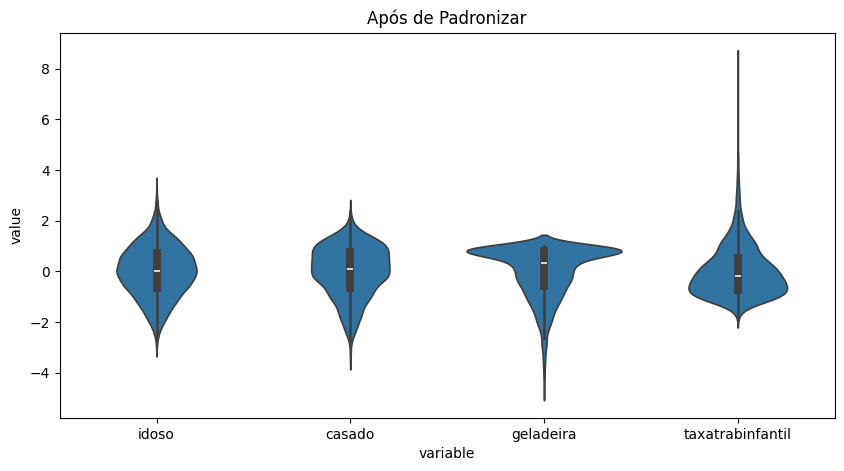

In [ ]:
X_train_tidy = X_train.melt()
plot = X_train_tidy[X_train_tidy['variable'].isin(['casado', 'idoso', 'geladeira', 'taxatrabinfantil'])]


plt.figure(figsize=(10,5))
sns.violinplot(data=plot, x= 'variable', y='value')
plt.title("Após de Padronizar")

#### Random Forest Regressor


Scikit Random Forest Regressor: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Grid Search vs. Random Search

![alt text](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ2DP4D5htDWBdhRUlhC6tbGuWIEK2wJo2mNcWIRfcT8LH7UhIH)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [ ]:
# modelo random forest
rf = RandomForestRegressor(random_state=42)

Hiperparâmetros a serem otimizados

In [ ]:
# Número de árvores no Random Forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Número de features a serem consideradas a cada split
max_features = ['sqrt'] # Corrected: Removed 'auto' as it's no longer supported for RandomForestRegressor
# Número máximo de níveis na árvore
max_depth = [int(x) for x in np.linspace(5, 30, num = 5)]
# Número mínimo de amostras necessárias para dividir um nó
min_samples_split = [2, 5, 10]
# Número mínimo de amostras necessárias em cada leaf node
min_samples_leaf = [1, 2, 4]
# Método de seleção das amostras para treinamento de cada árvore
bootstrap = [True]


# Criação do param grid
param_grid_rf = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

In [ ]:
# otimizando os hiperparâmetros
rf_random = RandomizedSearchCV(estimator = rf,
                               param_distributions = param_grid_rf,
                               n_iter = 10, ### número de avaliações do Random Grid
                               random_state = 42,
                               cv = 3,
                               verbose = 2,
                               n_jobs = -1)

# executando a busca
rf_random = rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# resultados da busca
print('Melhor score: %s' % rf_random.best_score_)
print('Melhores hiperparâmetros: %s' % rf_random.best_params_)

Melhor score: 0.7693558799054948
Melhores hiperparâmetros: {'n_estimators': 1600, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}


In [ ]:
# selecionando apenas os resultados da busca
rf = RandomForestRegressor(n_estimators = rf_random.best_params_['n_estimators'],
                           min_samples_split = rf_random.best_params_['min_samples_split'],
                           min_samples_leaf = rf_random.best_params_['min_samples_leaf'],
                           max_features = rf_random.best_params_['max_features'],
                           max_depth = rf_random.best_params_['max_depth'],
                           bootstrap = rf_random.best_params_['bootstrap'],
                           random_state=42)

# treinando o modelo otimizado
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=1600, random_state=42)

In [ ]:
# medidas de performance
pred_train_rf= rf.predict(X_train)
print('RMSE (treino):', np.sqrt(mean_squared_error(y_train,pred_train_rf)))
print('R² (treino):', r2_score(y_train, pred_train_rf))

pred_test_rf= rf.predict(X_test)
print('RMSE (teste):',np.sqrt(mean_squared_error(y_test,pred_test_rf)))
print('R² (teste):',r2_score(y_test, pred_test_rf))

RMSE (treino): 0.6321989517988457
R² (treino): 0.9470871620207328
RMSE (teste): 1.3085112753582309
R² (teste): 0.788301482078288


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ===== TREINO =====
pred_train_rf = rf.predict(X_train)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train_rf))
r2_train = r2_score(y_train, pred_train_rf)

rmse_rel_train = rmse_train / np.mean(y_train)

print('RMSE (treino):', rmse_train)
print('RMSE relativo (treino):', rmse_rel_train)
print('R² (treino):', r2_train)


# ===== TESTE =====
pred_test_rf = rf.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test_rf))
r2_test = r2_score(y_test, pred_test_rf)

rmse_rel_test = rmse_test / np.mean(y_test)

print('\nRMSE (teste):', rmse_test)
print('RMSE relativo (teste):', rmse_rel_test)
print('R² (teste):', r2_test)

RMSE (treino): 0.6321989517988457
RMSE relativo (treino): 0.008659777552288112
R² (treino): 0.9470871620207328

RMSE (teste): 1.3085112753582309
RMSE relativo (teste): 0.017944721647532
R² (teste): 0.788301482078288


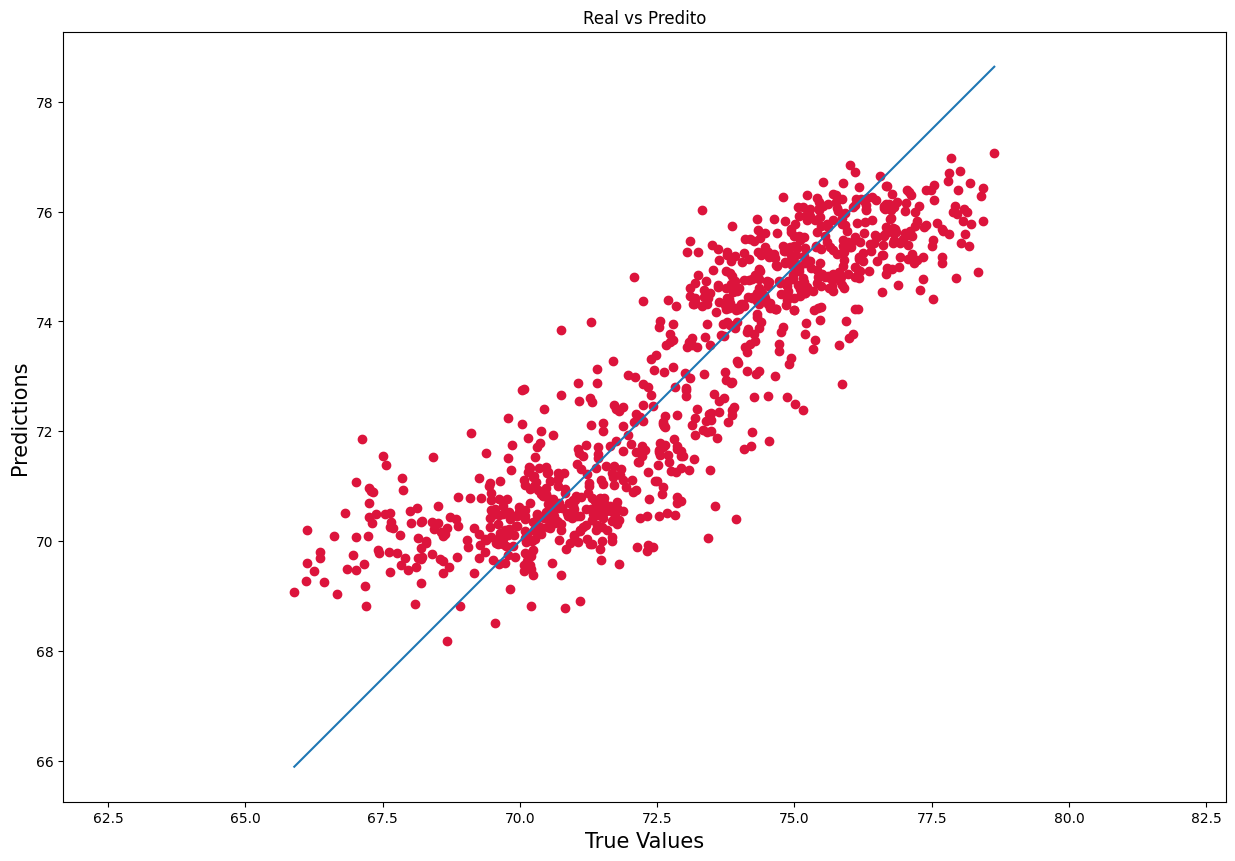

In [ ]:
import numpy as np
# gráfico de dispersão: valor real vs valor predito
plt.figure(figsize=(15,10))
plt.scatter(y_test, pred_test_rf, c='crimson')

p1 = max(pred_test_rf.max(), y_test.max())
p2 = min(pred_test_rf.min(), y_test.min())
plt.title("Real vs Predito")
plt.plot([p1, p2], [p1, p2])
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

#####Boruta

In [ ]:
# seleção de variáveis com boruta
! pip install boruta >> /dev/null
from boruta import BorutaPy

In [ ]:
# inicializa o Random Forest (max_depth de 3 a 7 segundo o git do Boruta)
rf_boruta = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=5)

# define o Boruta como método de seleção de variáveis
boruta = BorutaPy(estimator = rf_boruta, n_estimators = 'auto', verbose = 2, random_state = 42, max_iter = 10)

# fit Boruta no conjunto de treino
boruta.fit(np.array(X_train), np.array(y_train))

# obtendo os resultados
area_verde = X_train.columns[boruta.support_].to_list()
area_azul = X_train.columns[boruta.support_weak_].to_list()

print('variáveis na área verde:', area_verde)
print('variáveis na área azul:', area_azul)

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	20
Tentative: 	2
Rejected: 	0
Iteration: 	9 / 10
Confirmed: 	20
Tentative: 	1
Rejected: 	1


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	20
Tentative: 	1
Rejected: 	1
variáveis na área verde: ['PopResid', 'idoso', 'mulher', 'nascimentopercapta', 'casado', 'evangelico', 'deficiente', 'desindadepop', 'geladeira', 'pavimentacao', 'brancos', 'nvelsuperiorconcludo', 'conclusoensinomdio', 'ResideMenos10anos', 'resideoutranacionalid', 'taxadedesemprego', 'taxatrabinfantil', 'horastrabalho', 'CobBFamilia', 'traboutrmun']
variáve

In [ ]:
# Selecionar variáveis confirmadas (área verde)
X_train_sel = X_train[area_verde]
X_test_sel = X_test[area_verde]

In [ ]:
# Número de árvores no Random Forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Número de features a serem consideradas a cada split
max_features = ['sqrt'] # Corrected: Removed 'auto' as it's no longer supported for RandomForestRegressor
# Número máximo de níveis na árvore
max_depth = [int(x) for x in np.linspace(5, 30, num = 5)]
# Número mínimo de amostras necessárias para dividir um nó
min_samples_split = [2, 5, 10]
# Número mínimo de amostras necessárias em cada leaf node
min_samples_leaf = [1, 2, 4]
# Método de seleção das amostras para treinamento de cada árvore
bootstrap = [True]


# Criação do param grid
param_grid_rf = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_novo = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [ ]:
# otimizando os hiperparâmetros
rf_novo = RandomizedSearchCV(estimator = rf_novo, # Use the correctly initialized rf_novo
                               param_distributions = param_grid_rf,
                               n_iter = 10, ### número de avaliações do Random Grid
                               random_state = 42,
                               cv = 3,
                               verbose = 2,
                               n_jobs = -1)

# executando a busca
rf_novo = rf_novo.fit(X_train_sel, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
print('Melhores hiperparâmetros:')
print(rf_novo.best_params_)

Melhores hiperparâmetros:
{'n_estimators': 1600, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}


In [ ]:
# selecionando apenas os resultados da busca
rf_novo = RandomForestRegressor(n_estimators = rf_novo.best_params_['n_estimators'], # Use best_params_ from the search
                           min_samples_split = rf_novo.best_params_['min_samples_split'],
                           min_samples_leaf = rf_novo.best_params_['min_samples_leaf'],
                           max_features = rf_novo.best_params_['max_features'],
                           max_depth = rf_novo.best_params_['max_depth'],
                           bootstrap = rf_novo.best_params_['bootstrap'],
                           random_state=42)

# treinando o modelo otimizado
rf_novo.fit(X_train_sel, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=1600, random_state=42)

In [ ]:
# medidas de performance
pred_train_rf_novo = rf_novo.predict(X_train_sel)
print('RMSE (treino):', np.sqrt(mean_squared_error(y_train,pred_train_rf_novo)))
print('R² (treino):', r2_score(y_train, pred_train_rf_novo))

pred_test_rf_novo = rf_novo.predict(X_test_sel)
print('RMSE (teste):',np.sqrt(mean_squared_error(y_test,pred_test_rf_novo)))
print('R² (teste):',r2_score(y_test, pred_test_rf_novo))

RMSE (treino): 0.629945621069559
R² (treino): 0.947463681592608
RMSE (teste): 1.3053451035312646
R² (teste): 0.789324725780397


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ===== TREINO =====
pred_train_rf_novo = rf_novo.predict(X_train_sel)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train_rf_novo))
r2_train = r2_score(y_train, pred_train_rf_novo)

rmse_rel_train = rmse_train / np.mean(y_train)

print('RMSE (treino):', rmse_train)
print('RMSE relativo (treino):', rmse_rel_train)
print('R² (treino):', r2_train)


# ===== TESTE =====
pred_test_rf_novo = rf_novo.predict(X_test_sel)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test_rf_novo))
r2_test = r2_score(y_test, pred_test_rf_novo)

rmse_rel_test = rmse_test / np.mean(y_test)

print('\nRMSE (teste):', rmse_test)
print('RMSE relativo (teste):', rmse_rel_test)
print('R² (teste):', r2_test)

RMSE (treino): 0.629945621069559
RMSE relativo (treino): 0.00862891172625054
R² (treino): 0.947463681592608

RMSE (teste): 1.3053451035312646
RMSE relativo (teste): 0.017901301255829522
R² (teste): 0.789324725780397


#####Performance

In [ ]:
# Recalculate predictions for the Boruta model to ensure up-to-date values
pred_train_rf_novo = rf_novo.predict(X_train_sel)
pred_test_rf_novo = rf_novo.predict(X_test_sel)

comparacao = pd.DataFrame({
    'Modelo': ['Random Forest (antes)', 'Random Forest (Boruta)'],
    'RMSE Treino': [np.sqrt(mean_squared_error(y_train, pred_train_rf)), np.sqrt(mean_squared_error(y_train, pred_train_rf_novo))],
    'RMSE Teste': [np.sqrt(mean_squared_error(y_test, pred_test_rf)), np.sqrt(mean_squared_error(y_test, pred_test_rf_novo))],
    'R² Treino': [r2_score(y_train, pred_train_rf), r2_score(y_train, pred_train_rf_novo)],
    'R² Teste': [r2_score(y_test, pred_test_rf), r2_score(y_test, pred_test_rf_novo)]
})

display(comparacao)

,Modelo,RMSE Treino,RMSE Teste,R² Treino,R² Teste
0,Random Forest (antes),0.632199,1.308511,0.947087,0.788301
1,Random Forest (Boruta),0.629946,1.305345,0.947464,0.789325


🏆 Conclusão
👉 O Random Forest com Boruta é ligeiramente melhor, pois:

Tem menor erro (RMSE)
Explica um pouco mais da variância (R²)
Indica que a seleção de variáveis melhorou o modelo, mesmo que de forma sutil

⚠️ Observação importante
A diferença é muito pequena. Então, na prática:

Ambos os modelos têm desempenho quase equivalente
A escolha pode considerar:

Interpretabilidade (Boruta → menos variáveis)
Custo computacional
Simplicidade

#### Light GBM Regressor

In [ ]:
!pip install lightgbm >> /dev/null

from lightgbm import LGBMRegressor

In [ ]:
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

param_grid_lgbm = {
    'n_estimators': [200, 500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 5, 10, 15],
    'num_leaves': [31, 50, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 1, 5]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# modelo
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

# Random Search
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# treino
lgbm_random.fit(X_train, y_train)

# resultados
print("Melhor score:", lgbm_random.best_score_)
print("Melhores parâmetros:", lgbm_random.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000575 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4893
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 22
[LightGBM] [Info] Start training from score 73.004064
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Melhor score: 0.7712168956457351
Melhores parâmetros: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    **lgbm_random.best_params_,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4893
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 22
[LightGBM] [Info] Start training from score 73.004064
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.01, max_depth=15,
              n_estimators=500, n_jobs=-1, random_state=42, reg_alpha=0,
              reg_lambda=5, subsample=0.6)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# TREINO
pred_train_lgbm = lgbm.predict(X_train)

rmse_train_lgbm = np.sqrt(mean_squared_error(y_train, pred_train_lgbm))
r2_train_lgbm = r2_score(y_train, pred_train_lgbm)

# TESTE
pred_test_lgbm = lgbm.predict(X_test)

rmse_test_lgbm = np.sqrt(mean_squared_error(y_test, pred_test_lgbm))
r2_test_lgbm = r2_score(y_test, pred_test_lgbm)

print("RMSE Treino:", rmse_train_lgbm)
print("R² Treino:", r2_train_lgbm)
print("\nRMSE Teste:", rmse_test_lgbm)
print("R² Teste:", r2_test_lgbm)

RMSE Treino: 0.824493072674879
R² Treino: 0.9100031031716188

RMSE Teste: 1.314565698731803
R² Teste: 0.7863379106632582


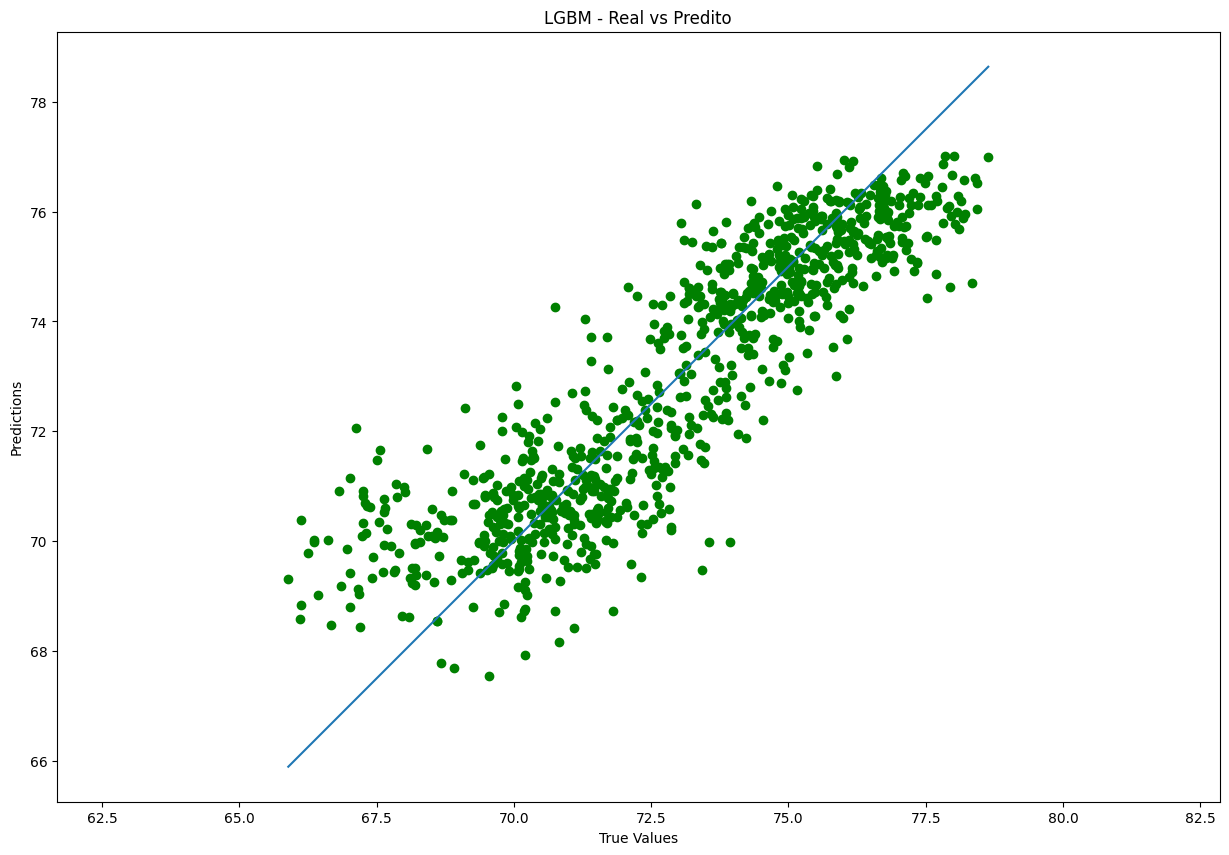

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.scatter(y_test, pred_test_lgbm, c='green')

p1 = max(pred_test_lgbm.max(), y_test.max())
p2 = min(pred_test_lgbm.min(), y_test.min())

plt.plot([p1, p2], [p1, p2])
plt.title("LGBM - Real vs Predito")
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.show()


#####Boruta

In [ ]:
from copy import deepcopy
from lightgbm import LGBMRegressor
from boruta import BorutaPy

lgbm_boruta = LGBMRegressor(
    **lgbm_random.best_params_,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=lgbm_boruta,
    n_estimators='auto',
    max_iter=30,
    verbose=2,
    random_state=42
)

boruta.fit(X_train.values, y_train.values)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9786
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 44
[LightGBM] [Info] Start training from score 73.004064
Iteration: 	1 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9786
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 44
[LightGBM] [Info] Start training from score 73.004064
Iteration: 	2 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 978

BorutaPy(estimator=LGBMRegressor(colsample_bytree=0.8, learning_rate=0.01,
                                 max_depth=15, n_estimators=43, n_jobs=-1,
                                 random_state=2542, reg_alpha=0, reg_lambda=5,
                                 subsample=0.6),
         max_iter=30, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7DC6AAD42C40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['PopResid', 'mulher', 'nascimentopercapta', 'casado', 'evangelico', 'deficiente', 'desindadepop', 'geladeira', 'moradorfavela', 'pavimentacao', 'brancos', 'nvelsuperiorconcludo', 'conclusoensinomdio', 'ResideMenos10anos', 'resideoutranacionalid', 'horastrabalho', 'CobBFamilia', 'traboutrmun']
❌ Features rejeitadas: ['taxatrabinfantil']
❓ Features tentativas: ['idoso', 'taxadedesemprego', 'Gini']


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

Shape do X_train após Boruta: (2136, 18)
Shape do X_test após Boruta: (916, 18)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# modelo
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

# Random Search
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 👉 usando as variáveis selecionadas pelo Boruta
lgbm_random.fit(X_train_novo, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4088
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 18
[LightGBM] [Info] Start training from score 73.004064


RandomizedSearchCV(cv=3, estimator=LGBMRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [-1, 5, 10, 15],
                                        'n_estimators': [200, 500, 1000, 1500],
                                        'num_leaves': [31, 50, 100, 150],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [0, 1, 5],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, verbose=2)

In [ ]:
print("Melhor score:", lgbm_random.best_score_)
print("Melhores parâmetros:", lgbm_random.best_params_)

Melhor score: 0.7694354680254323
Melhores parâmetros: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
from lightgbm import LGBMRegressor

lgbm_final = LGBMRegressor(
    **lgbm_random.best_params_,
    random_state=42,
    n_jobs=-1
)

lgbm_final.fit(X_train_novo, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4088
[LightGBM] [Info] Number of data points in the train set: 2136, number of used features: 18
[LightGBM] [Info] Start training from score 73.004064


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.01, max_depth=15,
              n_estimators=500, n_jobs=-1, random_state=42, reg_alpha=0,
              reg_lambda=5, subsample=0.6)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ===== TREINO =====
pred_train = lgbm_final.predict(X_train_novo)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
r2_train = r2_score(y_train, pred_train)

# ===== TESTE =====
pred_test = lgbm_final.predict(X_test_novo)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)

print("RMSE (treino):", rmse_train)
print("R² (treino):", r2_train)

print("\nRMSE (teste):", rmse_test)
print("R² (teste):", r2_test)

RMSE (treino): 0.8559776306511929
R² (treino): 0.9029985238344755

RMSE (teste): 1.3151512600457769
R² (teste): 0.7861475206067461


#####Performance

In [ ]:
comparacao_lgbm = pd.DataFrame({
    'Modelo': ['LGBM (antes)', 'LGBM (Boruta)'],
    'RMSE Treino': [rmse_train_lgbm, rmse_train],
    'RMSE Teste': [rmse_test_lgbm, rmse_test],
    'R² Treino': [r2_train_lgbm, r2_train],
    'R² Teste': [r2_test_lgbm, r2_test]
})

display(comparacao_lgbm)

,Modelo,RMSE Treino,RMSE Teste,R² Treino,R² Teste
0,LGBM (antes),0.824493,1.314566,0.910003,0.786338
1,LGBM (Boruta),0.855978,1.315151,0.902999,0.786148


#### CatBoost Regressor

In [ ]:
!pip install catboost >> /dev/null

from catboost import CatBoostRegressor


In [ ]:
cat = CatBoostRegressor(random_state=42, verbose=0)

param_grid_cat = {
    'iterations': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7],
    'bagging_temperature': [0, 0.5, 1],
    'border_count': [32, 64, 128]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

cat_random = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_grid_cat,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

cat_random.fit(X_train, y_train)

print("Melhor score:", cat_random.best_score_)
print("Melhores parâmetros:", cat_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhor score: 0.7711275718586653
Melhores parâmetros: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0}


In [ ]:
cat = CatBoostRegressor(
    **cat_random.best_params_,
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

CatBoostRegressor(bagging_temperature=0, border_count=128, depth=6, iterations=500, l2_leaf_reg=7, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# TREINO
pred_train_cat = cat.predict(X_train)
rmse_train_cat = np.sqrt(mean_squared_error(y_train, pred_train_cat))
r2_train_cat = r2_score(y_train, pred_train_cat)

# TESTE
pred_test_cat = cat.predict(X_test)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, pred_test_cat))
r2_test_cat = r2_score(y_test, pred_test_cat)

print("RMSE Treino:", rmse_train_cat)
print("R² Treino:", r2_train_cat)

print("\nRMSE Teste:", rmse_test_cat)
print("R² Teste:", r2_test_cat)

RMSE Treino: 0.7892711373739638
R² Treino: 0.9175281084195069

RMSE Teste: 1.3002236087650723
R² Teste: 0.790974642953236


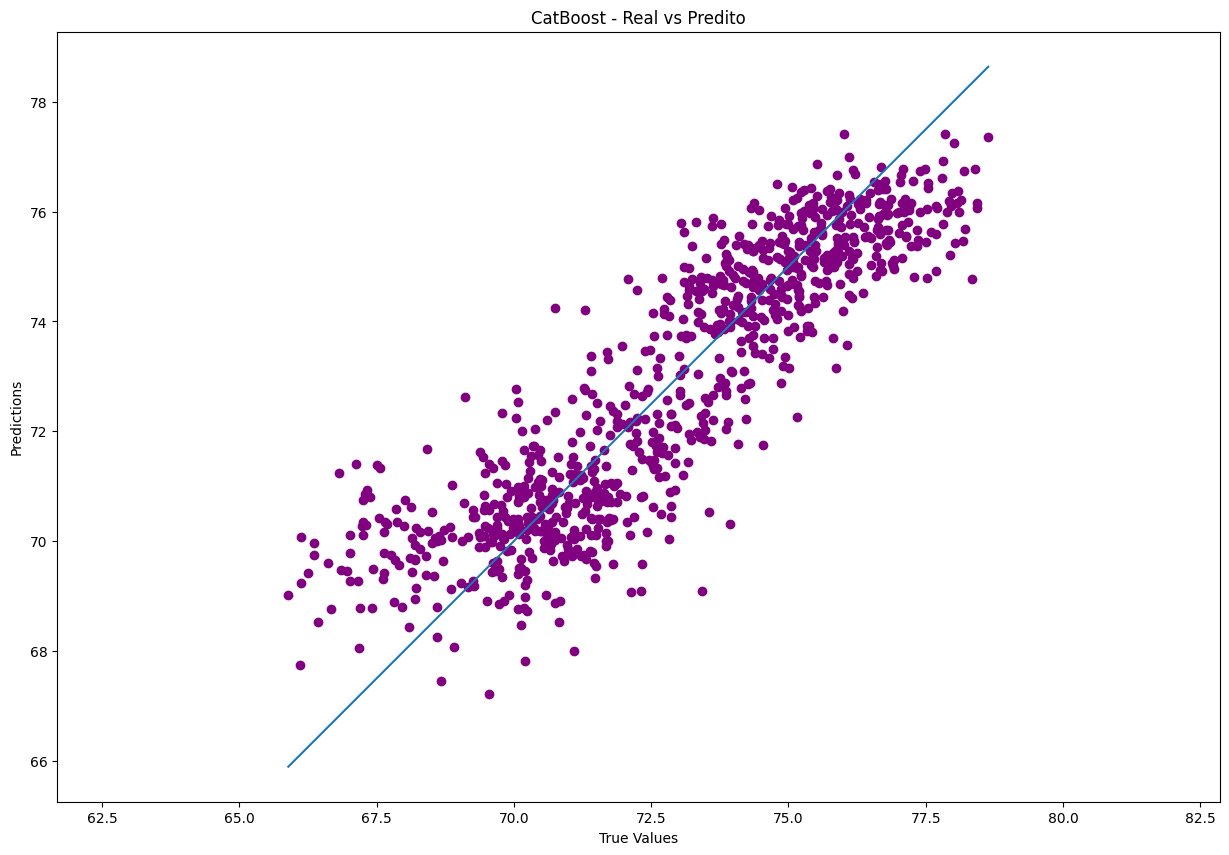

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.scatter(y_test, pred_test_cat, c='purple')

p1 = max(pred_test_cat.max(), y_test.max())
p2 = min(pred_test_cat.min(), y_test.min())

plt.plot([p1, p2], [p1, p2])
plt.title("CatBoost - Real vs Predito")
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.show()

#####Boruta

In [ ]:
from catboost import CatBoostRegressor
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params):
        # Store all parameters. We'll handle 'n_estimators' vs 'iterations' mapping internally.
        self.params = params.copy()
        self.model = None

        # CatBoost uses 'iterations', BorutaPy expects 'n_estimators'.
        # If 'n_estimators' is provided during init, use it as 'iterations'.
        if 'n_estimators' in self.params:
            self.params['iterations'] = self.params.pop('n_estimators')

    def fit(self, X, y):
        fit_params = self.params.copy()
        fit_params.pop('random_state', None) # CatBoost handles random_state separately or via its own parameter

        self.model = CatBoostRegressor(**fit_params)
        self.model.fit(X, y, verbose=0)

        # IMPORTANT: pegar as importâncias corretamente
        self.feature_importances_ = self.model.get_feature_importance()

        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        # BorutaPy expects 'n_estimators'. Map 'iterations' back to 'n_estimators' for Boruta.
        current_params = self.params.copy()
        if 'iterations' in current_params:
            current_params['n_estimators'] = current_params['iterations']
        return current_params

    def set_params(self, **params):
        # When BorutaPy calls set_params, it might set 'n_estimators'.
        # We need to map 'n_estimators' to 'iterations' or handle 'auto'.
        if 'n_estimators' in params:
            if params['n_estimators'] == 'auto':
                # If Boruta sets 'n_estimators' to 'auto', and we already have 'iterations' from __init__,
                # we prefer our explicit 'iterations'. So, we just remove Boruta's 'n_estimators' to avoid conflict.
                self.params.pop('n_estimators', None)
            else:
                # If Boruta sets a specific numeric 'n_estimators', use it as 'iterations'.
                self.params['iterations'] = params.pop('n_estimators')
        self.params.update(params) # Update other parameters if any
        return self

In [ ]:
cat_params = {
    **cat_random.best_params_,   # seus melhores parâmetros
    'random_state': 42,
    'verbose': 0,
    'loss_function': 'RMSE'  # ✅ importante para regressão
}

In [ ]:
cat_boruta = CatBoostWrapper(**cat_params)

In [ ]:
boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=50,      # ✅ 100 pode ser pesado
    verbose=2,
    random_state=42
)

boruta.fit(X_train.values, y_train.values)


/usr/local/lib/python3.12/dist-packages/boruta/boruta_py.py:460: UserWarning: The estimator does not have a max_depth property, as a result  the number of trees to use cannot be estimated automatically.
  warnings.warn(


Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	16
Tentative: 	6
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	16
Tentative: 	6
Rejected: 	0
Iteration: 	10 / 50
Confirmed: 	16
Tentative: 	6
Rejected: 	0
Iteration: 	11 / 50
Confirmed: 	16
Tentative: 	6
Rejected: 	0
Iteration: 	12 / 50
Confirmed: 	16
Tentative: 	6
Rejected: 	0
Iteration: 	13 / 50
Confirmed: 	16
Tentative: 	5
Rejected: 	1
Iteration: 	14 / 50
Confirmed: 	16
Tentative: 	5
Rejected: 	1
Iteration: 	15 / 50
Confirmed: 	16
Tentative: 	5
Rejected: 	1
Iteration: 	16 / 50
Confirmed: 	17
Tentative: 	4
Rejected: 	1
Iteration: 	17 / 

BorutaPy(estimator=CatBoostWrapper(bagging_temperature=0, border_count=128,
                                   depth=6, iterations=63, l2_leaf_reg=7,
                                   learning_rate=0.05, loss_function='RMSE',
                                   n_estimators=63,
                                   random_state=RandomState(MT19937) at 0x7DC6A9CBCC40,
                                   verbose=0),
         max_iter=50, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7DC6A9CBCC40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['PopResid', 'mulher', 'nascimentopercapta', 'casado', 'evangelico', 'deficiente', 'desindadepop', 'geladeira', 'moradorfavela', 'pavimentacao', 'brancos', 'nvelsuperiorconcludo', 'conclusoensinomdio', 'resideoutranacionalid', 'taxadedesemprego', 'horastrabalho', 'CobBFamilia', 'traboutrmun']
❌ Features rejeitadas: ['idoso', 'ResideMenos10anos', 'taxatrabinfantil', 'Gini']
❓ Features tentativas: []


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

Shape do X_train após Boruta: (2136, 18)
Shape do X_test após Boruta: (916, 18)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

# modelo
cat = CatBoostRegressor(random_state=42, verbose=0)

# Random Search
cat_random = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_grid_cat,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 👉 usando as variáveis selecionadas pelo Boruta
cat_random.fit(X_train_novo, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.5, 1],
                                        'border_count': [32, 64, 128],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [200, 500, 1000],
                                        'l2_leaf_reg': [1, 3, 5, 7],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, verbose=2)

In [ ]:
print("Melhor score:", cat_random.best_score_)
print("Melhores parâmetros:", cat_random.best_params_)


Melhor score: 0.7686020557621006
Melhores parâmetros: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0}


In [ ]:
from catboost import CatBoostRegressor

cat_final = CatBoostRegressor(
    **cat_random.best_params_,
    random_state=42,
    verbose=0
)

cat_final.fit(X_train_novo, y_train)

CatBoostRegressor(bagging_temperature=0, border_count=128, depth=6, iterations=500, l2_leaf_reg=7, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ===== TREINO =====
pred_train = cat_final.predict(X_train_novo)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
r2_train = r2_score(y_train, pred_train)

# ===== TESTE =====
pred_test = cat_final.predict(X_test_novo)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)

print("RMSE (treino):", rmse_train)
print("R² (treino):", r2_train)

print("\nRMSE (teste):", rmse_test)
print("R² (teste):", r2_test)

RMSE (treino): 0.820450896611713
R² (treino): 0.9108833811716064

RMSE (teste): 1.304865074754468
R² (teste): 0.7894796451179077


#####Performance

In [ ]:
comparacao_cat = pd.DataFrame({
    'Modelo': ['CatBoost (antes)', 'CatBoost (Boruta)'],
    'RMSE Treino': [rmse_train_cat, rmse_train],
    'RMSE Teste': [rmse_test_cat, rmse_test],
    'R² Treino': [r2_train_cat, r2_train],
    'R² Teste': [r2_test_cat, r2_test]
})

display(comparacao_cat)

,Modelo,RMSE Treino,RMSE Teste,R² Treino,R² Teste
0,CatBoost (antes),0.789271,1.300224,0.917528,0.790975
1,CatBoost (Boruta),0.820451,1.304865,0.910883,0.789480


#### XGBoost Regressor

In [ ]:
!pip install xgboost >> /dev/null

from xgboost import XGBRegressor

In [ ]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [200, 500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Melhor score:", xgb_random.best_score_)
print("Melhores parâmetros:", xgb_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Melhor score: 0.7634706857476106
Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


In [ ]:
xgb = XGBRegressor(**xgb_random.best_params_, random_state=42, n_jobs=-1)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# TREINO
pred_train_xgb = xgb.predict(X_train)

rmse_train_xgb = np.sqrt(mean_squared_error(y_train, pred_train_xgb))
r2_train_xgb = r2_score(y_train, pred_train_xgb)

# TESTE
pred_test_xgb = xgb.predict(X_test)

rmse_test_xgb = np.sqrt(mean_squared_error(y_test, pred_test_xgb))
r2_test_xgb = r2_score(y_test, pred_test_xgb)

print("RMSE Treino:", rmse_train_xgb)
print("R² Treino:", r2_train_xgb)
print("\nRMSE Teste:", rmse_test_xgb)
print("R² Teste:", r2_test_xgb)

RMSE Treino: 0.7025086068671702
R² Treino: 0.9359718108124082

RMSE Teste: 1.2331291461361353
R² Teste: 0.8032280025570291


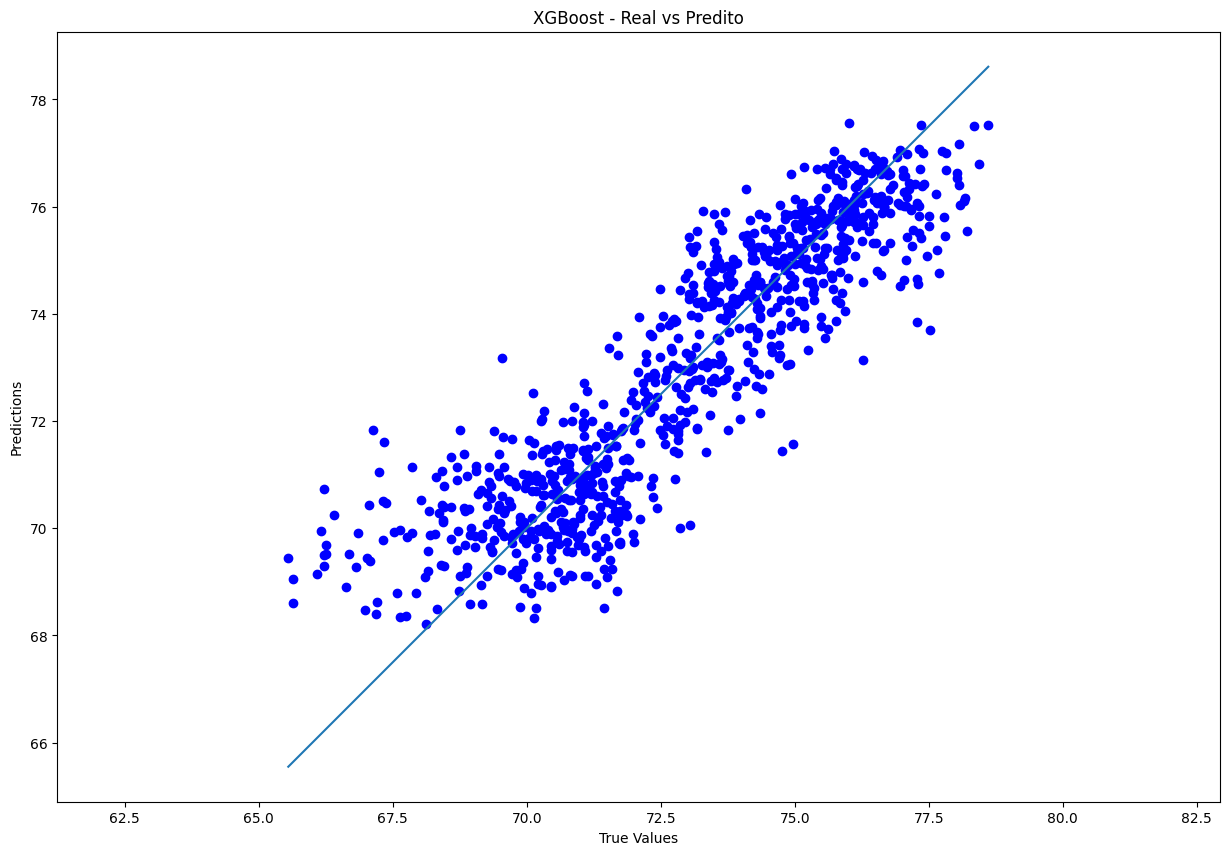

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.scatter(y_test, pred_test_xgb, c='blue')

p1 = max(pred_test_xgb.max(), y_test.max())
p2 = min(pred_test_xgb.min(), y_test.min())

plt.plot([p1, p2], [p1, p2])
plt.title("XGBoost - Real vs Predito")
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.show()

#####Boruta

In [ ]:
!pip install boruta >> /dev/null

In [ ]:
from copy import deepcopy
from xgboost import XGBRegressor
from boruta import BorutaPy

xgb_boruta = XGBRegressor(**xgb_random.best_params_, random_state=42, n_jobs=-1)

boruta = BorutaPy(
    estimator=xgb_boruta,
    n_estimators='auto',
    max_iter=30,   # ⚠️ 100 é exagerado aqui
    verbose=2,
    random_state=42
)

boruta.fit(X_train.values, y_train.values)

Iteration: 	1 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	2 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	3 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	4 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	5 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	6 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	7 / 30
Confirmed: 	0
Tentative: 	22
Rejected: 	0
Iteration: 	8 / 30
Confirmed: 	13
Tentative: 	7
Rejected: 	2
Iteration: 	9 / 30
Confirmed: 	13
Tentative: 	7
Rejected: 	2
Iteration: 	10 / 30
Confirmed: 	13
Tentative: 	7
Rejected: 	2
Iteration: 	11 / 30
Confirmed: 	13
Tentative: 	7
Rejected: 	2
Iteration: 	12 / 30
Confirmed: 	14
Tentative: 	6
Rejected: 	2
Iteration: 	13 / 30
Confirmed: 	14
Tentative: 	5
Rejected: 	3
Iteration: 	14 / 30
Confirmed: 	14
Tentative: 	5
Rejected: 	3
Iteration: 	15 / 30
Confirmed: 	14
Tentative: 	5
Rejected: 	3
Iteration: 	16 / 30
Confirmed: 	14
Tentative: 	4
Rejected: 	4
Iteration: 	17 / 

BorutaPy(estimator=XGBRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=0.8, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric=None,
                                feature_types=None, feature_weights=None,
                                gamma=0, grow_policy=None, importance_type=None,
                                interaction_constraints=None,
                                learning_rate=0.05, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=5,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=120,
                                n_jobs=-1, num_parallel_tree=None, ...),
         max_iter=30, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x798BDD50F940, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['nascimentopercapta', 'casado', 'evangelico', 'deficiente', 'desindadepop', 'geladeira', 'moradorfavela', 'pavimentacao', 'brancos', 'nvelsuperiorconcludo', 'conclusoensinomdio', 'ResideMenos10anos', 'resideoutranacionalid', 'horastrabalho', 'Gini']
❌ Features rejeitadas: ['PopResid', 'idoso', 'mulher', 'taxadedesemprego', 'CobBFamilia', 'traboutrmun']
❓ Features tentativas: ['taxatrabinfantil']


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

Shape do X_train após Boruta: (2136, 15)
Shape do X_test após Boruta: (916, 15)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 👉 usando as variáveis selecionadas
xgb_random.fit(X_train_novo, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=0,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=No...
                                          multi_strategy=None, n_estimators=200,
                                          n_jobs=-1, num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 1, 5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [200, 500, 1000, 1500],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, verbose=2)

In [ ]:
print("Melhor score:", xgb_random.best_score_)
print("Melhores parâmetros:", xgb_random.best_params_)

Melhor score: 0.7527911165715264
Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


In [ ]:
from xgboost import XGBRegressor

xgb_final = XGBRegressor(
    **xgb_random.best_params_,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train_novo, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ===== TREINO =====
pred_train = xgb_final.predict(X_train_novo)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
r2_train = r2_score(y_train, pred_train)

# ===== TESTE =====
pred_test = xgb_final.predict(X_test_novo)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)

print("RMSE (treino):", rmse_train)
print("R² (treino):", r2_train)

print("\nRMSE (teste):", rmse_test)
print("R² (teste):", r2_test)

RMSE (treino): 0.76889840068077
R² (treino): 0.9232981505626593

RMSE (teste): 1.2507937433334297
R² (teste): 0.7975500989299453


#####Performance

In [ ]:
comparacao = pd.DataFrame({
    'Modelo': ['XGBoost (antes)', 'XGBoost (Boruta)'],
    'RMSE Treino': [rmse_train_xgb, rmse_train],  # do modelo antigo vs novo
    'RMSE Teste': [rmse_test_xgb, rmse_test],
    'R² Treino': [r2_train_xgb, r2_train],
    'R² Teste': [r2_test_xgb, r2_test]
})

display(comparacao)

,Modelo,RMSE Treino,RMSE Teste,R² Treino,R² Teste
0,XGBoost (antes),0.702509,1.233129,0.935972,0.803228
1,XGBoost (Boruta),0.768898,1.250794,0.923298,0.797550


🧠 Interpretação (igual você já fez)
👉 O melhor modelo será o que tiver:

✅ menor RMSE (teste principalmente)
✅ maior R² (teste principalmente)

#####Shapley

In [ ]:
# importância de variáveis com SHAP
!pip install shap >> /dev/null
import shap

 98%|===================| 896/916 [00:16<00:00]       

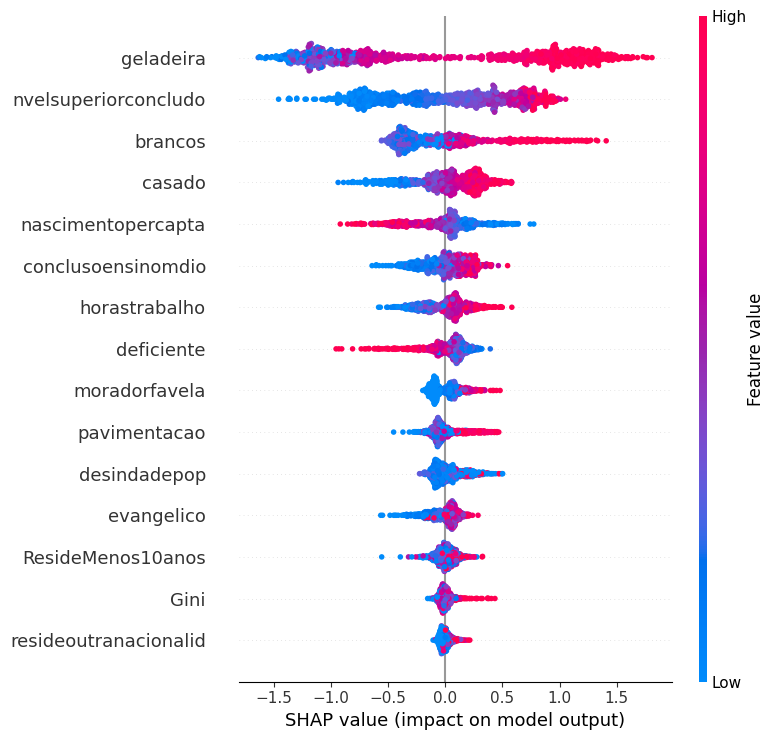

In [ ]:
explainer = shap.Explainer(xgb_final, X_test_novo)
shap_values = explainer(X_test_novo)
shap.summary_plot(shap_values, X_test_novo)

#### TabPFN Regressor

In [ ]:
!pip install tabpfn >> /dev/null


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os
os.environ["HF_TOKEN"] = "token1"
#site: https://ux.priorlabs.ai/home

In [ ]:
!pip install tabpfn-client >> /dev/null

In [ ]:
from tabpfn_client import TabPFNRegressor, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token("token2")
reg = TabPFNRegressor()
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

00:05 Fitting... Done!
00:05 Predicting... Done!


In [ ]:
tabpfn = TabPFNRegressor()

In [ ]:
tabpfn.fit(X_train, y_train)

00:00 Fitting... /

00:01 Fitting... Done!


TabPFNRegressor(client_options=ClientOptions(timeout=900.0,
                                             headers={'sentry-trace': '62589fb05dfa4f218355d8d7ca9d9939'}))

In [ ]:
pred_train_tabpfn = tabpfn.predict(X_train)
pred_test_tabpfn = tabpfn.predict(X_test)

00:06 Predicting... Done!
00:00 Predicting... \

00:11 Predicting... Done!


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# TREINO
rmse_train_tabpfn = np.sqrt(mean_squared_error(y_train, pred_train_tabpfn))
r2_train_tabpfn = r2_score(y_train, pred_train_tabpfn)

# TESTE
rmse_test_tabpfn = np.sqrt(mean_squared_error(y_test, pred_test_tabpfn))
r2_test_tabpfn = r2_score(y_test, pred_test_tabpfn)

print("RMSE Treino:", rmse_train_tabpfn)
print("R² Treino:", r2_train_tabpfn)

print("\nRMSE Teste:", rmse_test_tabpfn)
print("R² Teste:", r2_test_tabpfn)

RMSE Treino: 0.7604457419170666
R² Treino: 0.9249752796124143

RMSE Teste: 1.1544351170353713
R² Teste: 0.827541252791405


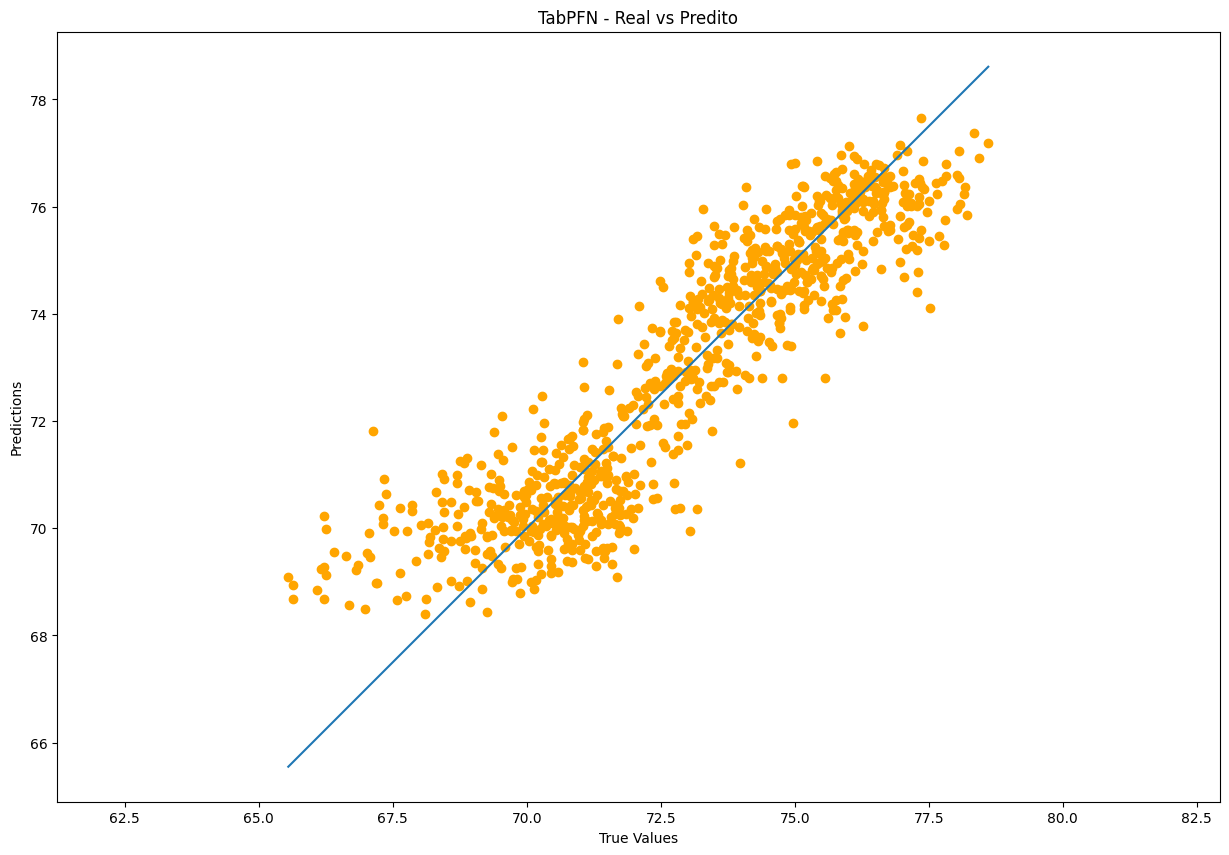

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.scatter(y_test, pred_test_tabpfn, c='orange')

p1 = max(pred_test_tabpfn.max(), y_test.max())
p2 = min(pred_test_tabpfn.min(), y_test.min())

plt.plot([p1, p2], [p1, p2])
plt.title("TabPFN - Real vs Predito")
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.show()

#####Performance

In [ ]:
comparacao_tabpfn = pd.DataFrame({
    'Modelo': ['TabPFN'],
    'RMSE Treino': [rmse_train_tabpfn],
    'RMSE Teste': [rmse_test_tabpfn],
    'R² Treino': [r2_train_tabpfn],
    'R² Teste': [r2_test_tabpfn]
})

display(comparacao_tabpfn)

,Modelo,RMSE Treino,RMSE Teste,R² Treino,R² Teste
0,TabPFN,0.760446,1.154435,0.924975,0.827541
